<a href="https://colab.research.google.com/github/maheshk2002/Barclays-FinancialRisk-Analysis-Python/blob/main/BarclaysFinancialRiskAnalysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd

file_path = '/content/drive/MyDrive/Barclays_Project/barclays_data.csv'
df = pd.read_csv(file_path)

# Preview the data
df.head()

,TransactionID,CustomerID,AccountID,AccountType,TransactionType,Product,Firm,Region,Manager,TransactionDate,TransactionAmount,AccountBalance,RiskScore,CreditRating,TenureMonths
0,118,CUST3810,ACC49774,Savings,Deposit,Credit Card,Firm D,West,Manager 4,08-01-2024,20664.409820,88483.42208,0.483333,522,29
1,102,CUST3109,ACC96277,Savings,Deposit,Mutual Fund,Firm B,North,Manager 4,17-12-2023,94924.359120,56670.15864,0.788989,686,130
2,151,CUST2626,ACC21429,Credit,Payment,Personal Loan,Firm C,West,Manager 1,22-05-2024,-7871.160407,84968.05587,0.547782,618,157
3,57,CUST3725,ACC48501,Loan,Withdrawal,Credit Card,Firm A,East,Manager 4,24-12-2023,24979.808160,115196.96420,0.125587,803,155
4,113,CUST4258,ACC11285,Loan,Transfer,Home Loan,Firm A,West,Manager 4,15-01-2023,72890.748550,111602.76610,1.048787,657,68


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   TransactionID      800 non-null    int64  
 1   CustomerID         800 non-null    object 
 2   AccountID          800 non-null    object 
 3   AccountType        800 non-null    object 
 4   TransactionType    800 non-null    object 
 5   Product            800 non-null    object 
 6   Firm               800 non-null    object 
 7   Region             800 non-null    object 
 8   Manager            800 non-null    object 
 9   TransactionDate    800 non-null    object 
 10  TransactionAmount  800 non-null    float64
 11  AccountBalance     800 non-null    float64
 12  RiskScore          800 non-null    float64
 13  CreditRating       800 non-null    int64  
 14  TenureMonths       800 non-null    int64  
dtypes: float64(3), int64(3), object(9)
memory usage: 93.9+ KB


# **Task 1: Data Cleaning and Formatting**

---




# 1.1 & 1.2


In [ ]:
import re
#list of ALL financial fields in the dataset
financial_fields = ['TransactionAmount', 'AccountBalance']

# Loop through each financial field to clean and convert them
for col in financial_fields:
    # Subtask 1.1: Remove special characters (£, $, commas, spaces)
    df[col] = df[col].astype(str).str.replace(r'[£$, ]', '', regex=True)

    # Subtask 1.2: Convert back to numerical format
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Quick check
print(df[['TransactionAmount', 'AccountBalance']].dtypes)

TransactionAmount    float64
AccountBalance       float64
dtype: object


# 1.3 - Validating and formating date columns.

In [ ]:
df['TransactionDate'] = pd.to_datetime(df['TransactionDate'], format='%d-%m-%Y', errors='coerce')
df['TransactionDate'].head(3)

,TransactionDate
0,2024-01-08
1,2023-12-17
2,2024-05-22


# 1.4 - Standardizing account types and transaction categories

In [ ]:
categorical_cols = ['AccountType', 'TransactionType', 'Product', 'Firm', 'Region', 'Manager']
for col in categorical_cols:
    df[col] = df[col].astype(str).str.strip().str.title()
df.iloc[:3, 3:9]

,AccountType,TransactionType,Product,Firm,Region,Manager
0,Savings,Deposit,Credit Card,Firm D,West,Manager 4
1,Savings,Deposit,Mutual Fund,Firm B,North,Manager 4
2,Credit,Payment,Personal Loan,Firm C,West,Manager 1


# Task 2: Descriptive Transactional **Analysis**

### Pre-Step: Standardizing Financial Math

In [ ]:
import numpy as np

# Create the explicit rulebook
transaction_rules = {
    'Deposit': 1,
    'Transfer': -1,
    'Withdrawal': -1,
    'Payment': -1
}

# Multiply the absolute amount by the mapped rule
df['NetTransaction'] = df['TransactionAmount'].abs() * df['TransactionType'].map(transaction_rules)

# Subtask 2.1: Monthly & Yearly Aggregations

In [ ]:
# Create a Year-Month period column
df['YearMonth'] = df['TransactionDate'].dt.to_period('M')

# Group, sum, and pivot the data
monthly_summary = (df.groupby(['YearMonth', 'TransactionType'])['NetTransaction']
                    .sum().unstack(fill_value=0))

# Add a Total Flow column across the row
monthly_summary['Net_Liquidity_Flow'] = monthly_summary.sum(axis=1)
monthly_summary.head(3)

TransactionType,Deposit,Payment,Transfer,Withdrawal,Net_Liquidity_Flow
YearMonth,,,,,
2023-01,569469.355020,-609319.83256,-982544.390280,-668336.92357,-1.690732e+06
2023-02,521830.583465,-664746.83586,-527550.173090,-817252.47485,-1.487719e+06
2023-03,342372.905660,-384349.98834,-391669.732642,-383576.63169,-8.172234e+05


# 2.2 Plot trends in total credits vs. debits over time.

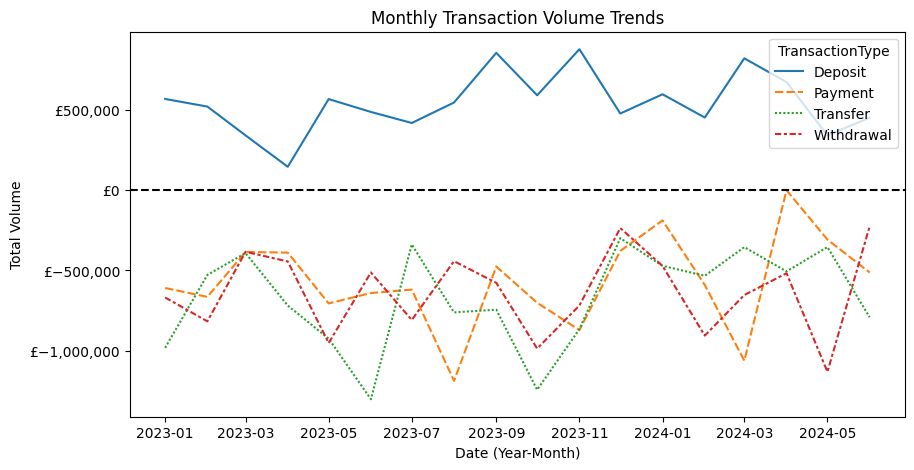

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker

plot_data = monthly_summary.drop(columns=['Net_Liquidity_Flow']).copy()

plot_data.index = plot_data.index.to_timestamp()

plt.figure(figsize=(10, 5))
ax = sns.lineplot(data=plot_data)

#Drew a zero-line to easily separate Money In (above) from Money Out (below)
plt.axhline(0, color='black', linestyle='--')

plt.title('Monthly Transaction Volume Trends')
plt.ylabel('Total Volume')
plt.xlabel('Date (Year-Month)')

#Y-axis readable with a simple currency formatter (e.g., £500,000)
ax.yaxis.set_major_formatter(ticker.StrMethodFormatter('£{x:,.0f}'))

plt.show()

# 2.3 Identify top and bottom performing accounts based on net inflow.

In [ ]:
#Group by AccountID and calculate the total net cash flow per account
account_performance = df.groupby('AccountID')['NetTransaction'].sum()

#Sorting the accounts from highest positive balance to lowest negative balance
account_performance_sorted = account_performance.sort_values(ascending=False)

print("--- TOP 5 PERFORMING ACCOUNTS (Highest Net Inflow) ---")
print(account_performance_sorted.head(5))

print("\n--- BOTTOM 5 PERFORMING ACCOUNTS (Highest Net Outflow) ---")
print(account_performance_sorted.tail(5))

--- TOP 5 PERFORMING ACCOUNTS (Highest Net Inflow) ---
AccountID
ACC76549    178514.787150
ACC39544    142078.535970
ACC64022    120503.785830
ACC95164    116682.838910
ACC21878     86417.091881
Name: NetTransaction, dtype: float64

--- BOTTOM 5 PERFORMING ACCOUNTS (Highest Net Outflow) ---
AccountID
ACC49140   -377859.70172
ACC19178   -384900.83747
ACC25132   -448761.32916
ACC46655   -449599.01096
ACC54589   -597407.08601
Name: NetTransaction, dtype: float64


# 2.4 Identify and flag accounts as dormant or inactive if there is a gap of two months or more between consecutive transactions.

In [ ]:
#Sort by Account, then chronologically by Date (Oldest to Newest)
df = df.sort_values(by=['AccountID', 'TransactionDate'])

#Calculating the gap in days between the current and previous transaction per account
df['DaysSinceLastTxn'] = df.groupby('AccountID')['TransactionDate'].diff().dt.days

#Filtering gaps >= 60 days and extract the unique Account IDs
dormant_accounts_list = df[df['DaysSinceLastTxn'] >= 60]['AccountID'].unique()

#Printing the final counts and a sample for the slide
print(f"Total Dormant Accounts Detected (60+ Days Inactive): {len(dormant_accounts_list)}")
print(f"Sample of Dormant Account IDs: \n{', '.join(dormant_accounts_list[:3])}")

Total Dormant Accounts Detected (60+ Days Inactive): 166
Sample of Dormant Account IDs: 
ACC10117, ACC10996, ACC11062


# **Task 3: Customer Profile Building**


# 3.1 Group accounts by activity levels: High, Medium, Low

In [ ]:
customer_profile = df.groupby('AccountID')['TransactionID'].count().reset_index()
#customer_profile
customer_profile.rename(columns={'TransactionID': 'TxnFrequency'}, inplace=True)
#customer_profile
#Defining the exact mathematical rules (The Rubric)
conditions = [
    (customer_profile['TxnFrequency'] > 5),
    (customer_profile['TxnFrequency'] >= 3) & (customer_profile['TxnFrequency'] <= 5),
    (customer_profile['TxnFrequency'] < 3)
]

#Defining the labels that perfectly match the rules above
choices = ['High Activity', 'Medium Activity', 'Low Activity']

#Apply the rules to create our new category column
customer_profile['ActivityLevel'] = np.select(conditions, choices, default='Unknown')

# Check our work: How many customers are in each bucket?
print("--- CUSTOMER ACTIVITY SEGMENTATION ---")
print(customer_profile['ActivityLevel'].value_counts())

--- CUSTOMER ACTIVITY SEGMENTATION ---
ActivityLevel
Medium Activity    113
Low Activity        43
High Activity       37
Name: count, dtype: int64


# 3.2 Segment customers by average balance and transaction volume.

In [ ]:

#Creating absolute volume
df['AbsoluteVolume'] = df['TransactionAmount'].abs()

#Calculating MEDIAN balance and SUM of volume per account
account_metrics = df.groupby('AccountID').agg(
    MedianBalance=('AccountBalance', 'median'),
    TotalVolume=('AbsoluteVolume', 'sum')).reset_index()

#Merge these new numbers into our main customer_profile table
customer_profile = customer_profile.merge(account_metrics, on='AccountID', how='left')
#Finding the mathematical middle for the whole bank to use as our split-point
bank_median_balance = customer_profile['MedianBalance'].median()
bank_median_volume = customer_profile['TotalVolume'].median()

#Segmentation Rules using the new MedianBalance
conditions = [
    (customer_profile['MedianBalance'] >= bank_median_balance) & (customer_profile['TotalVolume'] >= bank_median_volume),
    (customer_profile['MedianBalance'] >= bank_median_balance) & (customer_profile['TotalVolume'] < bank_median_volume),
    (customer_profile['MedianBalance'] < bank_median_balance) & (customer_profile['TotalVolume'] >= bank_median_volume),
    (customer_profile['MedianBalance'] < bank_median_balance) & (customer_profile['TotalVolume'] < bank_median_volume)
]
# Defining the Labels
choices = [
    'High Balance / High Volume',
    'High Balance / Low Volume',
    'Low Balance / High Volume',
    'Low Balance / Low Volume'
]
#Applying the labels to create our segments
customer_profile['ValueSegment'] = np.select(conditions, choices, default='Unknown')

print(f"Bank Split-Point (Balance): £{bank_median_balance:,.2f}")
print(f"Bank Split-Point (Volume): £{bank_median_volume:,.2f}\n")
print("--- CUSTOMER SEGMENTATION TOTALS ---")
print(customer_profile['ValueSegment'].value_counts())

Bank Split-Point (Balance): £72,225.36
Bank Split-Point (Volume): £217,538.41

--- CUSTOMER SEGMENTATION TOTALS ---
ValueSegment
High Balance / High Volume    55
Low Balance / Low Volume      54
Low Balance / High Volume     42
High Balance / Low Volume     42
Name: count, dtype: int64


# 3.3 Persona Profiling: a)High-Net Inflow

In [ ]:
#Filtering the master table (The VIP Bouncer)
premium_clients = customer_profile[customer_profile['ValueSegment'] == 'High Balance / High Volume']

#Extracting just the Account IDs into a clean list
vip_account_list = premium_clients['AccountID'].tolist()

#Printing the results
print("--- PERSONA 1: THE PREMIUM CLIENT ---")
print(f"Total VIP Clients Identified: {len(vip_account_list)}")
print(f"Sample Accounts for Wealth Management: {', '.join(vip_account_list[:5])}")

--- PERSONA 1: THE PREMIUM CLIENT ---
Total VIP Clients Identified: 55
Sample Accounts for Wealth Management: ACC10117, ACC11188, ACC11285, ACC15228, ACC15925


## 3.3 Persona Profiling: b)High-Freq/Low-Balance

In [ ]:
#Filtering the master table for the high-maintenance/high-risk segment
high_risk_clients = customer_profile[customer_profile['ValueSegment'] == 'Low Balance / High Volume']

#Extracting just the Account IDs into a clean list
risk_account_list = high_risk_clients['AccountID'].tolist()

#Printing the results
print("--- PERSONA 2: THE HIGH-RISK CUSTOMER ---")
print(f"Total High-Risk Accounts Identified: {len(risk_account_list)}")
print(f"Sample Accounts for Risk Monitoring: {', '.join(risk_account_list[:5])}")

--- PERSONA 2: THE HIGH-RISK CUSTOMER ---
Total High-Risk Accounts Identified: 42
Sample Accounts for Risk Monitoring: ACC10996, ACC12334, ACC13357, ACC16241, ACC19178


# 3.3 Persona Profiling: c)Negative/Near-Zero

In [ ]:
#The "Ghost Account" Filter - Requires BOTH conditions to be true
dormant_clients = customer_profile[
    (customer_profile['ActivityLevel'] == 'Low Activity') &
    (customer_profile['ValueSegment'] == 'Low Balance / Low Volume')
]

#Extracting just the Account IDs into a clean list
dormant_account_list = dormant_clients['AccountID'].tolist()

#Printing the results
print("--- PERSONA 3: THE ATTRITION RISK (Ghost Accounts) ---")
print(f"Total Ghost Accounts Identified: {len(dormant_account_list)}")
print(f"Sample Accounts for Re-engagement: {', '.join(dormant_account_list[:5])}")


--- PERSONA 3: THE ATTRITION RISK (Ghost Accounts) ---
Total Ghost Accounts Identified: 20
Sample Accounts for Re-engagement: ACC11062, ACC11837, ACC15359, ACC18177, ACC28612


# Task 4: Financial Risk Identification

# 4.1 Tracking accounts with frequent large withdrawals or overdrafts.

In [ ]:
#Mathematically define a "Large Withdrawal" (Top 15% of all withdrawals)
withdrawals_only = df[df['TransactionType'] == 'Withdrawal']['TransactionAmount'].abs()
large_withdrawal_limit = withdrawals_only.quantile(0.85)

# Event A: large withdrawals
is_large_withdrawal = (df['TransactionType'] == 'Withdrawal') & (df['TransactionAmount'].abs() >= large_withdrawal_limit)

# Event B: overdrafts?
is_overdraft = df['AccountBalance'] < 0

#Create a single Risk Event column (True if Event A OR Event B happens)
df['RiskEventFlag'] = is_large_withdrawal | is_overdraft

#Track the accounts (Group by AccountID and count the flags)
risk_tracking = df.groupby('AccountID')['RiskEventFlag'].sum().reset_index()

#Isolate the accounts where these events are "frequent" (e.g., 3 or more times)
frequent_offenders = risk_tracking[risk_tracking['RiskEventFlag'] >= 3]
flagged_accounts_list = frequent_offenders['AccountID'].tolist()

# Printing the final, clean report
print("--- 🚨 FRAUD & RISK TRACKING: 4.1 ---")
print(f"Large Withdrawal Threshold (95th Percentile): > £{large_withdrawal_limit:,.2f}")
print(f"Total Accounts Flagged for Frequent Risk: {len(flagged_accounts_list)}")
print(f"Sample Flagged Accounts: {', '.join(flagged_accounts_list[:5])}")

--- 🚨 FRAUD & RISK TRACKING: 4.1 ---
Large Withdrawal Threshold (95th Percentile): > £86,645.83
Total Accounts Flagged for Frequent Risk: 1
Sample Flagged Accounts: ACC45521


4.2 Calculating balance volatility using standard deviation or coefficient of variation.

In [ ]:
#Calculating both the Mean and the Standard Deviation of the daily balance for each account
volatility_df = df.groupby('AccountID').agg(
    MeanBalance=('AccountBalance', 'mean'),
    StdDevBalance=('AccountBalance', 'std')
).reset_index()

#Handling Edge Cases (The Data Engineering Safety Nets)
#If an account only has 1 transaction ever, Pandas gives it a NaN (blank) standard deviation. Fill it with 0.
volatility_df['StdDevBalance'] = volatility_df['StdDevBalance'].fillna(0)

#Calculating the Coefficient of Variation (CV) = Standard Deviation / Mean
# We use .abs() on the mean just in case the average balance is negative.
# We add a tiny number (+ 0.0001) to the denominator to prevent a fatal "Divide by Zero" error if the mean is exactly 0.
volatility_df['CV'] = volatility_df['StdDevBalance'] / (volatility_df['MeanBalance'].abs() + 0.0001)

#Defining "High Volatility"
# A CV > 1.0 means the account's daily fluctuations are larger than the account's actual average balance.
high_volatility_accounts = volatility_df[volatility_df['CV'] > 1.0]

#Extracting the list of volatile accounts
volatile_account_list = high_volatility_accounts['AccountID'].tolist()

# Printing the results
print("--- 📈 VOLATILITY TRACKING: 4.2 ---")
print(f"Total Highly Volatile Accounts (CV > 1.0): {len(volatile_account_list)}")
print(f"Sample Volatile Accounts: {', '.join(volatile_account_list[:5]) if volatile_account_list else 'None'}")

--- 📈 VOLATILITY TRACKING: 4.2 ---
Total Highly Volatile Accounts (CV > 1.0): 7
Sample Volatile Accounts: ACC11285, ACC29646, ACC42467, ACC55331, ACC70460


# 4.3-Using IQR or z-score methods to detect anomalies.

In [ ]:
#Using absolute values so we evaluate the sheer size of the transaction
amounts = df['TransactionAmount'].abs()

#Calculating the 25th percentile (Q1) and 75th percentile (Q3)
Q1 = amounts.quantile(0.25)
Q3 = amounts.quantile(0.75)

#Calculating the Interquartile Range (The "Box" of normal behavior)
IQR = Q3 - Q1

# Defining the Upper Boundary for Anomalies
# The industry standard is 1.5 times the IQR above the 75th percentile
iqr_upper_bound = Q3 + (1.5 * IQR)

#Flagging the specific transactions that break the boundary
df['Is_IQR_Anomaly'] = amounts > iqr_upper_bound

#Group by Account to see who is generating these anomalies
anomaly_tracking = df.groupby('AccountID')['Is_IQR_Anomaly'].sum().reset_index()

# Extract accounts that have generated at least one mathematical anomaly
# (You can change > 0 to >= 3 if you want to track frequent anomalies again)
anomalous_accounts = anomaly_tracking[anomaly_tracking['Is_IQR_Anomaly'] > 0]['AccountID'].tolist()

# Print the professional output
print("--- 🕵️‍♂️ ANOMALY DETECTION: 4.3 (IQR Method) ---")
print(f"Typical Transaction Range (Middle 50%): £{Q1:,.2f} to £{Q3:,.2f}")
print(f"Mathematical Anomaly Threshold: > £{iqr_upper_bound:,.2f}")
print(f"Total Accounts with Anomalous Transactions: {len(anomalous_accounts)}")

--- 🕵️‍♂️ ANOMALY DETECTION: 4.3 (IQR Method) ---
Typical Transaction Range (Middle 50%): £33,527.85 to £74,158.87
Mathematical Anomaly Threshold: > £135,105.40
Total Accounts with Anomalous Transactions: 4


# 4.4-Highlight customers with irregular or suspicious transaction behavior.

In [ ]:
# We use .agg() to sum up the anomalies and risk events per account
suspicion_metrics = df.groupby('AccountID').agg(
    Total_IQR_Anomalies=('Is_IQR_Anomaly', 'sum'),
    Total_Risk_Events=('RiskEventFlag', 'sum')
).reset_index()

#Bringing in the Volatility (CV) data we built in Task 4.2
master_risk_profile = pd.merge(suspicion_metrics, volatility_df[['AccountID', 'CV']], on='AccountID', how='left')

# Step 3: Build the Composite "Suspicion Score"
master_risk_profile['Suspicion_Score'] = 0

# Award points based on the thresholds we established in previous tasks
master_risk_profile.loc[master_risk_profile['Total_IQR_Anomalies'] >= 3, 'Suspicion_Score'] += 1
master_risk_profile.loc[master_risk_profile['Total_Risk_Events'] >= 3, 'Suspicion_Score'] += 1
master_risk_profile.loc[master_risk_profile['CV'] > 1.0, 'Suspicion_Score'] += 1

#Highlight the "Highly Suspicious" customers (Score of 1 or more)
highly_suspicious_df = master_risk_profile[master_risk_profile['Suspicion_Score'] >= 1]
suspicious_list = highly_suspicious_df['AccountID'].tolist()

# Print the Final Risk Matrix
print("--- 🚨 FINAL SUSPICIOUS ACTIVITY REPORT (SAR): 4.4 ---")
print(f"Total Highly Suspicious Accounts (2+ overlapping risk factors): {len(suspicious_list)}")
print(f"Sample Targets for Investigation: {', '.join(suspicious_list[:5]) if suspicious_list else 'None Detected'}")

--- 🚨 FINAL SUSPICIOUS ACTIVITY REPORT (SAR): 4.4 ---
Total Highly Suspicious Accounts (2+ overlapping risk factors): 8
Sample Targets for Investigation: ACC11285, ACC29646, ACC42467, ACC45521, ACC55331


# Task 5: Visualisation

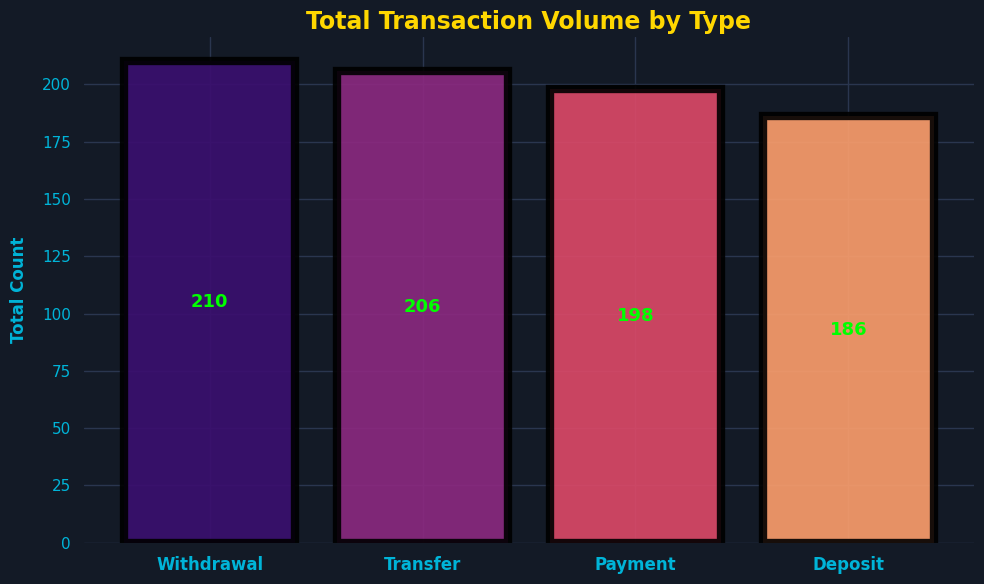

In [ ]:
sns.set_theme(style="darkgrid", rc={"axes.facecolor": "#131A26",
              "figure.facecolor": "#131A26", "grid.color": "#2A364F"})
plt.figure(figsize=(10, 6))

# Data Prep
counts = df['TransactionType'].value_counts()
categories, values = counts.index, counts.values

bars = plt.bar(
    categories, values,
    color=sns.color_palette('magma', len(categories)),
    edgecolor='#000000',
    linewidth=6.0,
    alpha=0.9 )

# Data Labels
plt.gca().bar_label(
    bars, labels=[f'{v:,}' for v in values],
    label_type='center',
    color='#00FF00',
    fontweight='bold', fontsize=13)

#Premium Typography (Pacific Blue for the axes, Gold for the title)
plt.title('Total Transaction Volume by Type', color='#FFD700', fontsize=17, fontweight='bold')
plt.ylabel('Total Count', color='#00B4D8', fontsize=12, fontweight='bold', labelpad=10)

plt.xticks(color='#00B4D8', fontsize=12, fontweight='bold')
plt.yticks(color='#00B4D8', fontsize=11)

# Clean number formatting for the Y-axis
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: f"{int(x):,}"))

# Remove the outer box to let the bars float seamlessly
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

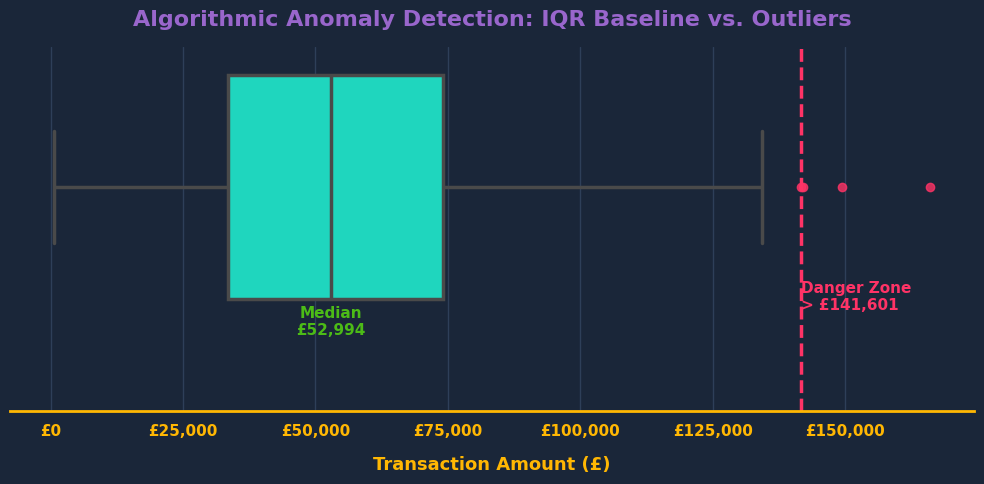

In [ ]:
sns.set_theme(style="darkgrid", rc={"axes.facecolor": "#1A2639", "figure.facecolor": "#1A2639",
                                    "grid.color": "#2E3F59"})
plt.figure(figsize=(10, 5))

amounts = df['TransactionAmount'].abs()
median = amounts.median()
threshold = amounts[df['Is_IQR_Anomaly'] == True].min()

ax = sns.boxplot(
    x=amounts, color="#00F5D4",  linewidth=2.5, fliersize=6,
    flierprops={"markerfacecolor": "#FF3366", "markeredgecolor": "#FF3366", "alpha": 0.8} )

# Anomaly Boundary Line
plt.axvline(threshold, color='#FF3366', linestyle='--', linewidth=2.5)

# Expanding the invisible Y-axis to give the text breathing room at the top
plt.ylim(-0.8, 0.5)

plt.text(median, -0.54, f'Median\n£{median:,.0f}', color='#4cbb17', ha='center', va='bottom',
         fontweight='bold', fontsize=11)
plt.text(threshold, -0.45, f'Danger Zone\n> £{threshold:,.0f}', color='#FF3366', ha='left',
         va='bottom', fontweight='bold', fontsize=11)

plt.title('Algorithmic Anomaly Detection: IQR Baseline vs. Outliers', color='#9966CC',
          fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Transaction Amount (£)', color='#FFB703', fontsize=13, fontweight='bold', labelpad=12)

plt.xticks(color='#00F5D4', fontsize=11, fontweight='bold')
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: f"£{int(x):,}"))

sns.despine(left=True, top=True, right=True, bottom=False)
ax.spines['bottom'].set_color('#FFB703')
ax.spines['bottom'].set_linewidth(2.0)
ax.tick_params(axis='x', colors='#FFB703', width=2, length=6)
plt.tight_layout()
plt.show()

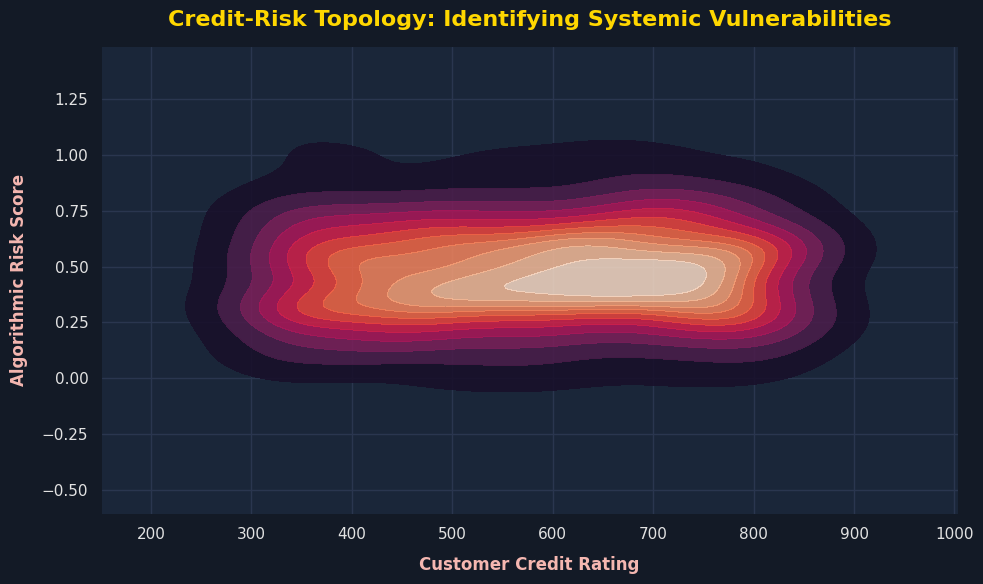

In [ ]:
sns.set_theme(style="darkgrid", rc={"axes.facecolor": '#1A2639',
             "figure.facecolor": "#131A26", "grid.color": "#2A364F"})
plt.figure(figsize=(10, 6))

x_data = df['CreditRating']
y_data = df['RiskScore']

# thresh=0.05 removes the outer noise
# levels=12 creates the distinct topographical rings
sns.kdeplot(
    x=x_data, y=y_data,
    fill=True,
    cmap="rocket",
    thresh=0.05,
    levels=12,
    alpha=0.85
)

plt.title('Credit-Risk Topology: Identifying Systemic Vulnerabilities',
              color='#FFD700', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Customer Credit Rating', color='#F5B7B1', fontsize=12,
                                  fontweight='bold', labelpad=10)
plt.ylabel('Algorithmic Risk Score', color='#F5B7B1', fontsize=12,
                                   fontweight='bold', labelpad=10)

plt.xticks(color='#E2E2E2', fontsize=11)
plt.yticks(color='#E2E2E2', fontsize=11)

sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

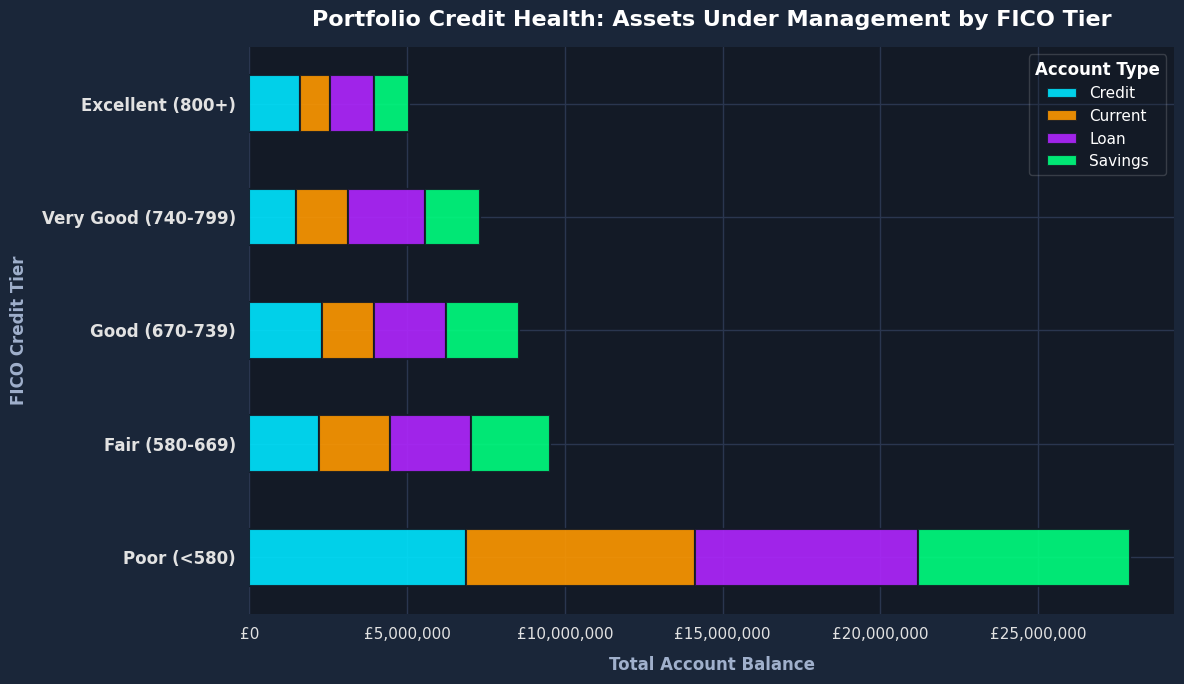

In [ ]:
sns.set_theme(style="darkgrid", rc={"axes.facecolor": '#131A26',
             "figure.facecolor": "#1A2639", "grid.color": "#2A364F"})
fig, ax = plt.subplots(figsize=(12, 7))

# Realworld FICO Credit Tiering
bins = [0, 579, 669, 739, 799, 999]
labels = ['Poor (<580)', 'Fair (580-669)', 'Good (670-739)', 'Very Good (740-799)', 'Excellent (800+)']
df['CreditTier'] = pd.cut(df['CreditRating'], bins=bins, labels=labels)

final_matrix = df.groupby(['CreditTier', 'AccountType']
                 , observed=True)['AccountBalance'].sum().unstack().fillna(0)

colors = ['#00E5FF', '#FF9800', '#B026FF', '#00FF7F'][:len(final_matrix.columns)]

final_matrix.plot(kind='barh', stacked=True, color=colors, ax=ax, edgecolor='#131A26',
                linewidth=1.5, alpha=0.9)

plt.title('Portfolio Credit Health: Assets Under Management by FICO Tier', color='#FFFFFF',
                                                    fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Total Account Balance', color='#A0B0CC', fontsize=12, fontweight='bold', labelpad=10)
plt.ylabel('FICO Credit Tier', color='#A0B0CC', fontsize=12, fontweight='bold', labelpad=10)

plt.xticks(color='#E2E2E2', fontsize=11)
plt.yticks(color='#E2E2E2', fontsize=12, fontweight='bold')

ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: f"£{int(x):,}"))

# 5. Clean, Floating Legend
legend = ax.legend(title='Account Type', loc='upper right', framealpha=0.2, fontsize=11)
plt.setp(legend.get_texts(), color='#FFFFFF')
plt.setp(legend.get_title(), color='#FFFFFF', fontweight='bold')

sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

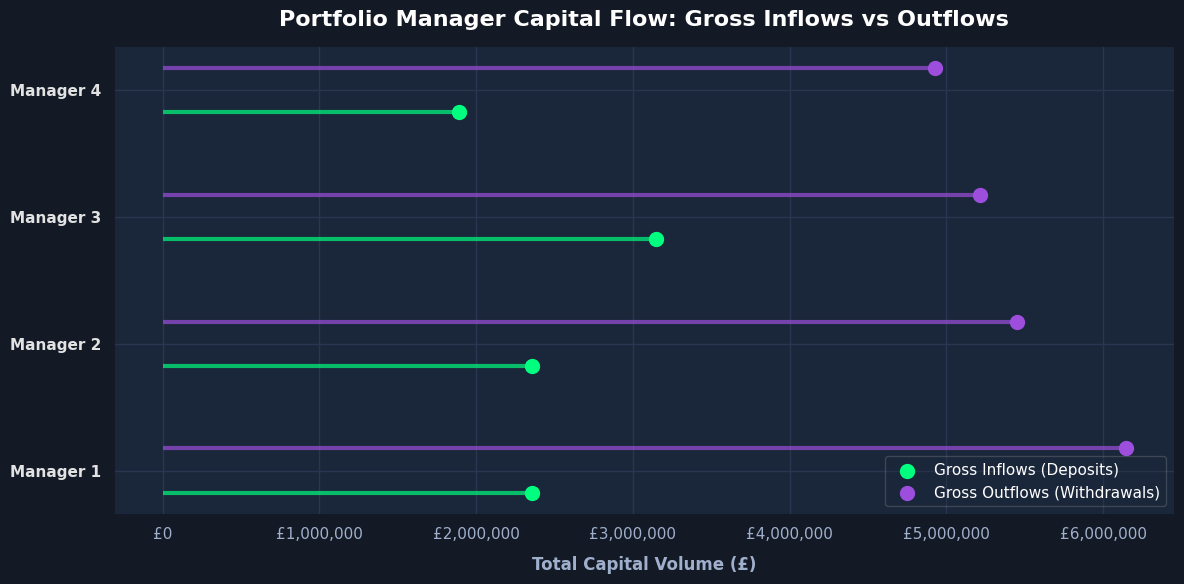

In [ ]:
sns.set_theme(style="darkgrid", rc={"axes.facecolor": '#1A2639', "figure.facecolor": "#131A26", "grid.color": "#2A364F"})
plt.figure(figsize=(12, 6))

df['TxType_Clean'] = df['TransactionType'].fillna('').str.strip().str.lower()

# Isolate inflows vs outflows and force absolute values
inflows = df[df['TxType_Clean'] == 'deposit'].copy()
outflows = df[df['TxType_Clean'].isin(['withdrawal', 'payment'])].copy()

inflows['TrueAmount'] = inflows['TransactionAmount'].abs()
outflows['TrueAmount'] = outflows['TransactionAmount'].abs()

in_grouped = inflows.groupby('Manager')['TrueAmount'].sum()
out_grouped = outflows.groupby('Manager')['TrueAmount'].sum()

# Align the data index (in case a manager has 0 of one type)
managers = np.sort(df['Manager'].unique())
in_vals = in_grouped.reindex(managers, fill_value=0).values
out_vals = out_grouped.reindex(managers, fill_value=0).values

# 3. Draw the Dual Lollipop Chart
y_pos = np.arange(len(managers))
height = 0.35 # Space between the two lollipops per manager

# Draw the stems (lines)
plt.hlines(y=y_pos - height/2, xmin=0, xmax=in_vals, color='#00FF7F', linewidth=3, alpha=0.7)  # Emerald Green
plt.hlines(y=y_pos + height/2, xmin=0, xmax=out_vals, color='#9D4EDD', linewidth=3, alpha=0.7) # Amethyst Purple

# Draw the candies (dots)
plt.scatter(in_vals, y_pos - height/2, color='#00FF7F', s=100, zorder=3, label='Gross Inflows (Deposits)')
plt.scatter(out_vals, y_pos + height/2, color='#9D4EDD', s=100, zorder=3, label='Gross Outflows (Withdrawals)')

# 4. Premium Typography
plt.title('Portfolio Manager Capital Flow: Gross Inflows vs Outflows', color='#FFFFFF', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Total Capital Volume (£)', color='#A0B0CC', fontsize=12, fontweight='bold', labelpad=10)
plt.yticks(y_pos, managers, color='#E2E2E2', fontsize=11, fontweight='bold')
plt.xticks(color='#A0B0CC', fontsize=11)

plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: f"£{int(x):,}"))

# Floating Legend
legend = plt.legend(loc='lower right', framealpha=0.2, fontsize=11)
plt.setp(legend.get_texts(), color='#FFFFFF')

sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

# Task 6: Hypothesis Testing

# 6.1-Testing whether high-volume transaction accounts have statistically higher average balances than low-volume accounts.

In [ ]:
from scipy import stats

# Aggregating data to the Account level
account_stats = df.groupby('AccountID').agg(
    TxnCount=('TransactionID', 'count'),
    AvgBalance=('AccountBalance', 'mean')
).reset_index()

# Finding the median to create a fair split
median_txns = account_stats['TxnCount'].median()

# Split into High and Low volume groups
high_vol = account_stats[account_stats['TxnCount'] > median_txns]['AvgBalance']
low_vol = account_stats[account_stats['TxnCount'] <= median_txns]['AvgBalance']

# Run the Right-Tailed Independent T-Test
t_stat, p_val = stats.ttest_ind(high_vol, low_vol, alternative='greater')

# 4. Print the Executive Summary
print("--- HYPOTHESIS TEST RESULTS ---")
print(f"Split Threshold: {median_txns} transactions")
print(f"High-Volume Accounts (n={len(high_vol)}): £{high_vol.mean():,.2f} Avg Balance")
print(f"Low-Volume Accounts  (n={len(low_vol)}): £{low_vol.mean():,.2f} Avg Balance")
print("-" * 30)
print(f"T-Statistic: {t_stat:.4f}")
print(f"P-Value:     {p_val:.4f}")

# Automating Decision Logic
if p_val < 0.05:
    print("\nConclusion: REJECT the Null Hypothesis. High-volume accounts have statistically higher balances.")
else:
    print("\nConclusion: FAIL TO REJECT the Null Hypothesis. High-volume accounts do NOT have statistically higher balances.")

--- HYPOTHESIS TEST RESULTS ---
Split Threshold: 4.0 transactions
High-Volume Accounts (n=70): £71,919.57 Avg Balance
Low-Volume Accounts  (n=123): £74,829.28 Avg Balance
------------------------------
T-Statistic: -1.1021
P-Value:     0.8641

Conclusion: FAIL TO REJECT the Null Hypothesis. High-volume accounts do NOT have statistically higher balances.


6.2-Conducting hypothesis testing based on segmentation.

In [ ]:
#Isolating the segments (Account Types)
segments = df['AccountType'].unique()

# Extracting the Account Balances for each segment into a list of arrays
grouped_balances = [df[df['AccountType'] == segment]['AccountBalance'] for segment in segments]

# Runing the One-Way ANOVA Test
f_stat, p_val = stats.f_oneway(*grouped_balances)

# Printing the Executive Summary
print("--- ANOVA SEGMENTATION TEST RESULTS ---")
for segment in segments:
    mean_val = df[df['AccountType'] == segment]['AccountBalance'].mean()
    count_val = len(df[df['AccountType'] == segment])
    print(f"{segment.ljust(10)} (n={count_val}): £{mean_val:,.2f} Avg Balance")

print("-" * 40)
print(f"F-Statistic: {f_stat:.4f}")
print(f"P-Value:     {p_val:.4f}")

# Automating Decision Logic
if p_val < 0.05:
    print("\nConclusion: REJECT the Null Hypothesis. Account balances vary significantly by Account Type.")
else:
    print("\nConclusion: FAIL TO REJECT the Null Hypothesis. Liquidity is evenly distributed across account segments.")

--- ANOVA SEGMENTATION TEST RESULTS ---
Savings    (n=195): £73,415.11 Avg Balance
Loan       (n=206): £76,521.48 Avg Balance
Current    (n=198): £69,405.05 Avg Balance
Credit     (n=201): £72,212.27 Avg Balance
----------------------------------------
F-Statistic: 1.5211
P-Value:     0.2076

Conclusion: FAIL TO REJECT the Null Hypothesis. Liquidity is evenly distributed across account segments.
